In [1]:
import os
import re
import pandas as pd
from datetime import datetime, timedelta
from scipy.stats import zscore
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler


In [2]:
def doy_to_datetime(year: int, doy: int, hour: int, minute: int, second: float=0.0):
    return datetime(year, 1, 1) + timedelta(days=doy - 1, hours=hour, minutes=minute, seconds=second)

def parse_fengyun_line(line: str):
    pattern = r'(\S+)\s+(\S+)\s+"([^"]+)"\s+"([^"]+)"'
    match = re.match(pattern, line)
    if not match:
        print(f"Line did not match Fengyun format: {line}")
        return None

    sat_code = match.group(1)
    sat_id = f"{sat_code} {match.group(2)}"
    start_str = match.group(3).split()[0]  # Remove timezone if present
    end_str = match.group(4).split()[0]

    try:
        start_dt = datetime.fromisoformat(start_str)
        end_dt = datetime.fromisoformat(end_str)
    except Exception as e:
        print(f"Error parsing timestamps: {line}\n{e}")
        return None

    return {'satellite': sat_id, 'start_time': start_dt, 'end_time': end_dt}

def process_fengyun_manoeuvre_file(filepath: str):
    records = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = parse_fengyun_line(line)
            if rec:
                records.append(rec)
    return pd.DataFrame(records)

def load_orbital_elements(filepath: str):
    try:
        df = pd.read_csv(filepath, index_col=0, parse_dates=True)
        df.sort_index(inplace=True)
        df.index.name = 'timestamp'  # renamed from 'epoch' to 'timestamp'
        return df
    except Exception as e:
        print(f"Error loading orbital elements file: {filepath}\n{e}")
        return pd.DataFrame()

def main():
    base_dir = './satellite_data'
    manoeuvre_file = os.path.join(base_dir, 'manoeuvres', 'manFY2F.txt.fy')
    orbital_file = os.path.join(base_dir, 'orbital_elements', 'Fengyun-2F.csv')

    # Process Fengyun manoeuvre file
    print(f"Processing Fengyun manoeuvre file: {manoeuvre_file}")
    df_manoeuvre = process_fengyun_manoeuvre_file(manoeuvre_file)
    print("Fengyun manoeuvre data:")
    print(df_manoeuvre.head())

    # Process Fengyun orbital elements file
    print(f"Processing Fengyun orbital elements file: {orbital_file}")
    df_orbital = load_orbital_elements(orbital_file)
    print("Fengyun orbital element data:")
    print(df_orbital.head())

    return df_manoeuvre, df_orbital
    return man_df, orb_df 

In [3]:
man_df, orb_df = main()

Processing Fengyun manoeuvre file: ./satellite_data/manoeuvres/manFY2F.txt.fy
Fengyun manoeuvre data:
                          satellite          start_time            end_time
0  GEO-EW-STATION-KEEPING 2012-002A 2022-01-05 08:30:00 2022-01-05 09:30:00
1  GEO-EW-STATION-KEEPING 2012-002A 2021-11-15 15:30:00 2021-11-15 16:30:00
2  GEO-EW-STATION-KEEPING 2012-002A 2021-09-23 16:00:00 2021-09-23 17:00:00
3  GEO-EW-STATION-KEEPING 2012-002A 2021-08-04 15:00:00 2021-08-04 16:00:00
4  GEO-EW-STATION-KEEPING 2012-002A 2021-06-15 16:00:00 2021-06-15 17:00:00
Processing Fengyun orbital elements file: ./satellite_data/orbital_elements/Fengyun-2F.csv
Fengyun orbital element data:
                            eccentricity  argument of perigee  inclination  \
timestamp                                                                    
2012-09-06 18:48:32.050655      0.000488             4.483911     0.032940   
2012-09-07 19:39:45.383327      0.000487             4.481215     0.032901   
2012-09-0

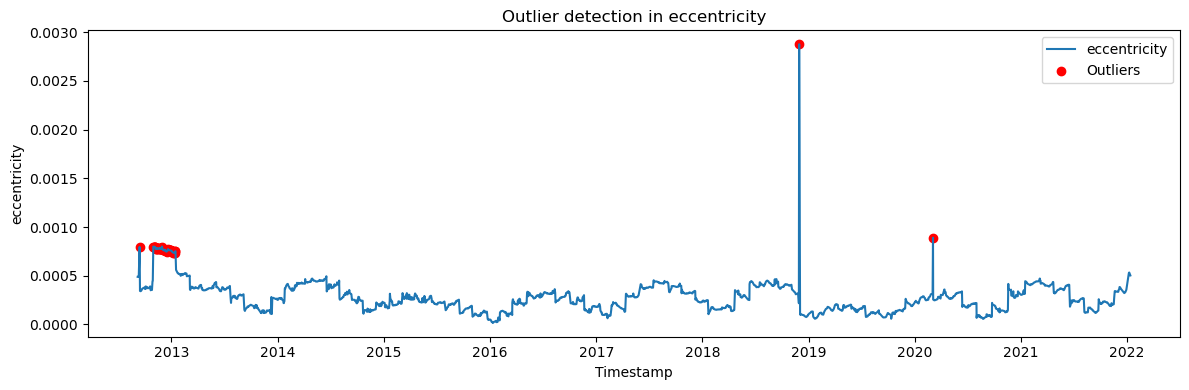

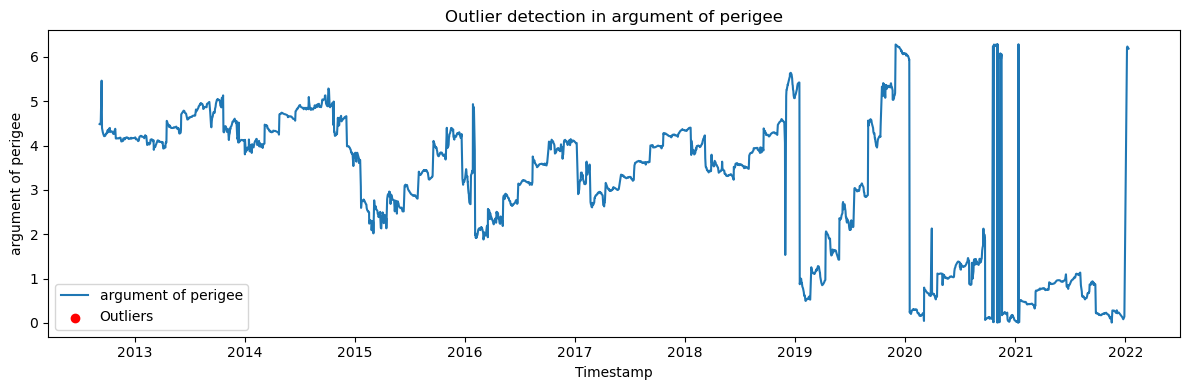

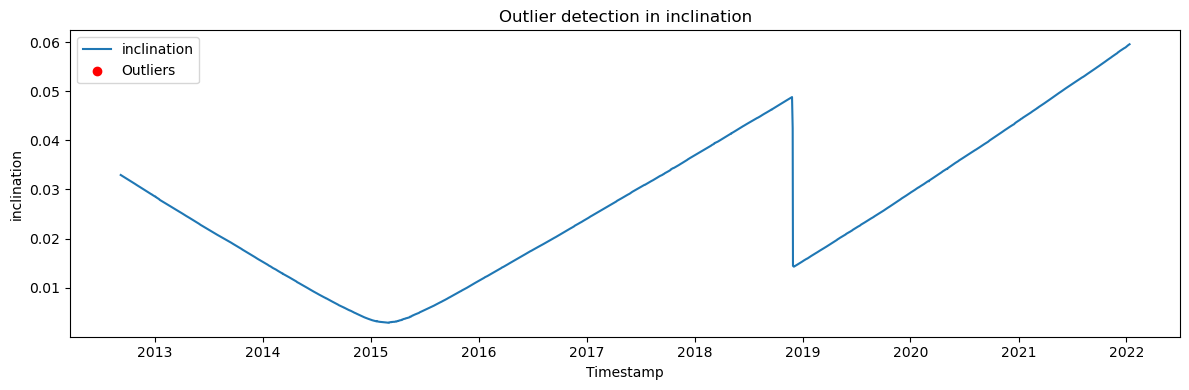

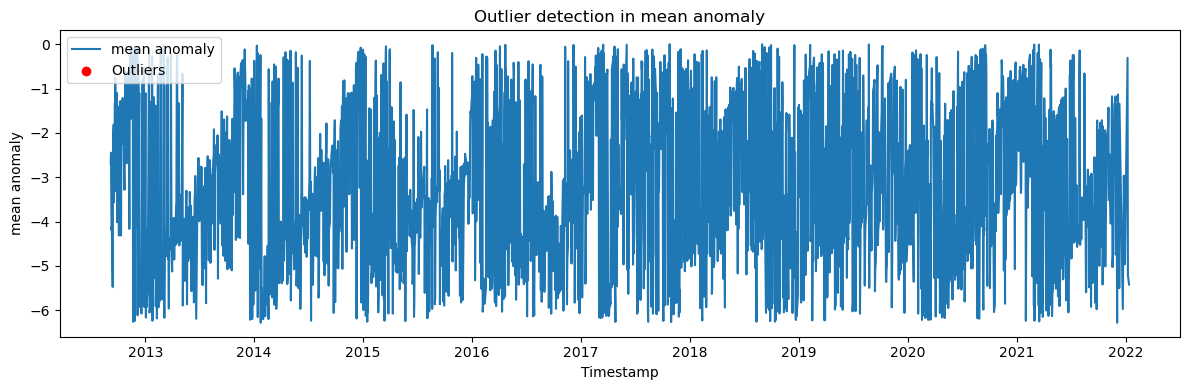

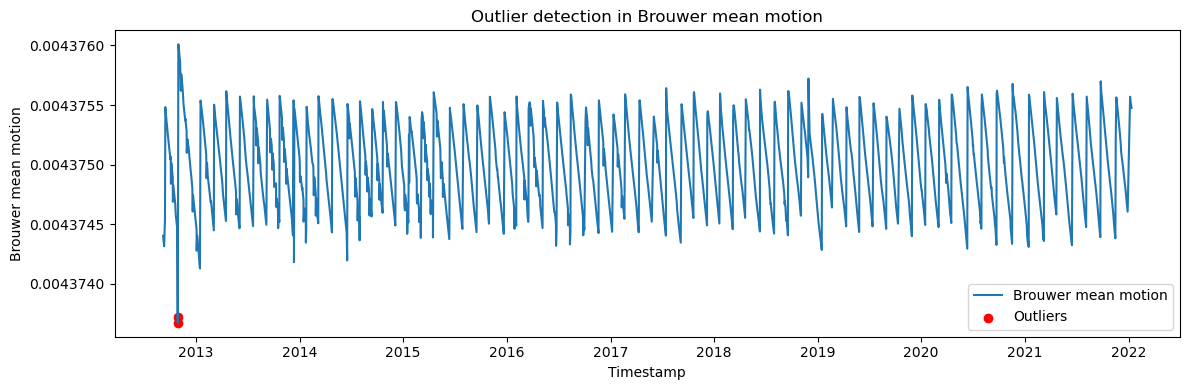

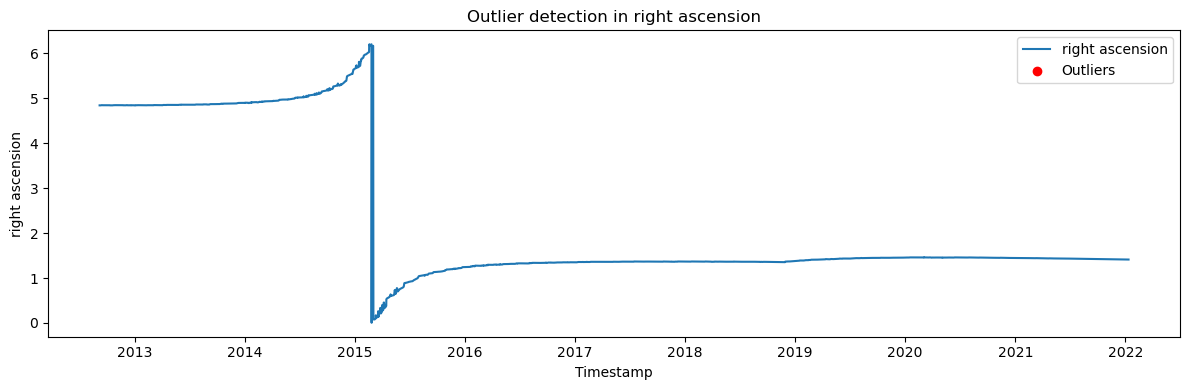

In [4]:
#Detecting outliers
def detect_outliers(df, threshold=3):
    z_scores = df.apply(zscore)  # Z-score across columns
    outliers = (z_scores.abs() > threshold)
    return outliers

def plot_outliers(df, outliers):
    for col in df.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(df.index, df[col], label=col)
        plt.scatter(df.index[outliers[col]], df[col][outliers[col]], color='red', label='Outliers')
        plt.title(f"Outlier detection in {col}")
        plt.legend()
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
outliers = detect_outliers(orb_df)
plot_outliers(orb_df, outliers)


--- Descriptive Statistics ---
       eccentricity  argument of perigee  inclination  mean anomaly  \
count   2985.000000          2985.000000  2985.000000   2985.000000   
mean       0.000268             3.080858     0.027013     -3.231240   
std        0.000141             1.578471     0.014476      1.782625   
min        0.000016             0.002423     0.002838     -6.281169   
25%        0.000164             1.880957     0.015568     -4.662804   
50%        0.000253             3.512791     0.026058     -3.432794   
75%        0.000360             4.236199     0.038343     -1.669105   
max        0.002877             6.283074     0.059559     -0.002337   

       Brouwer mean motion  right ascension  
count         2.985000e+03      2985.000000  
mean          4.375000e-03         2.187677  
std           3.378075e-07         1.567024  
min           4.373674e-03         0.003768  
25%           4.374719e-03         1.359957  
50%           4.375006e-03         1.424098  
75%   

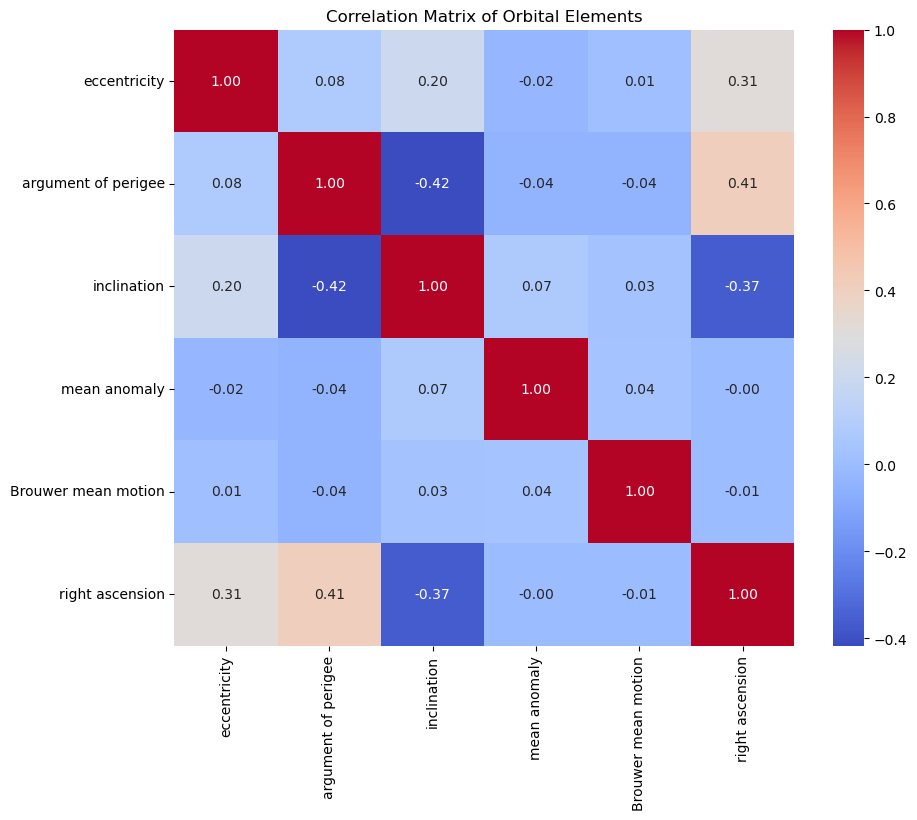

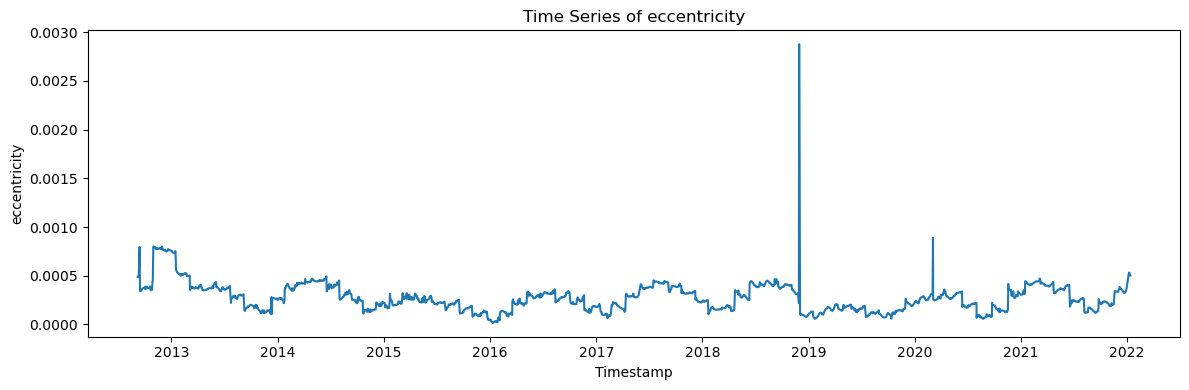

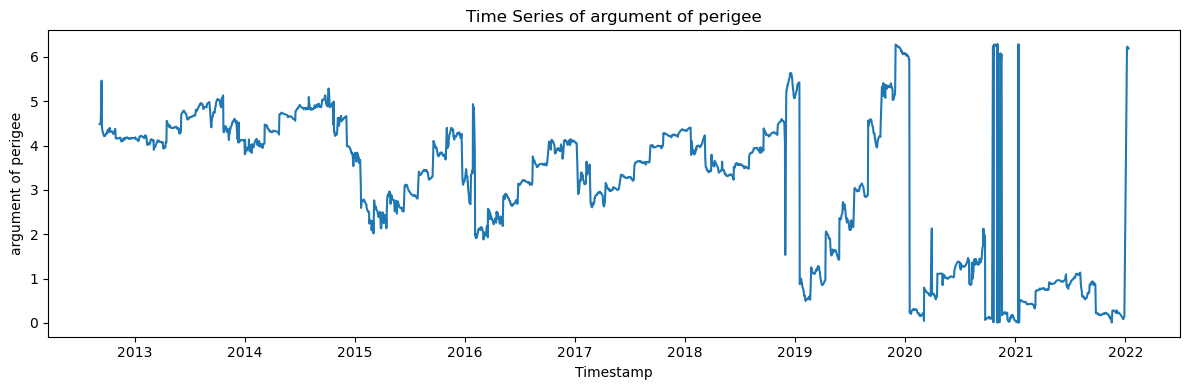

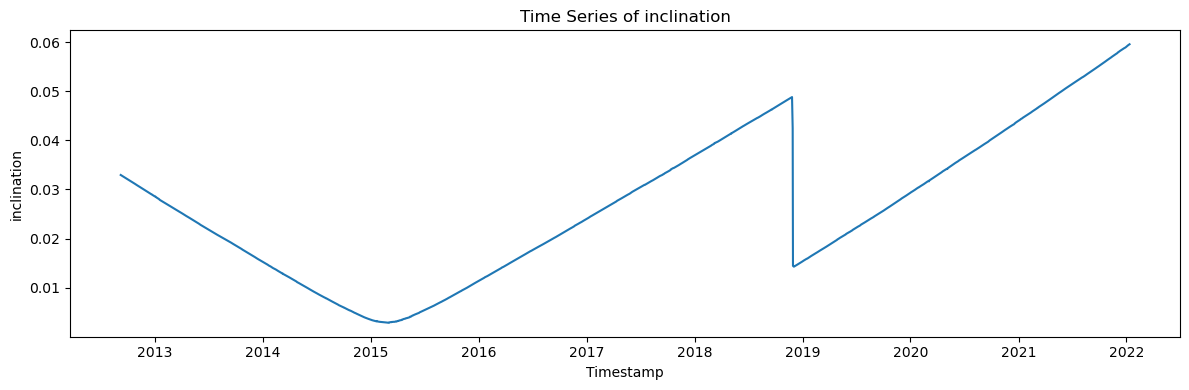

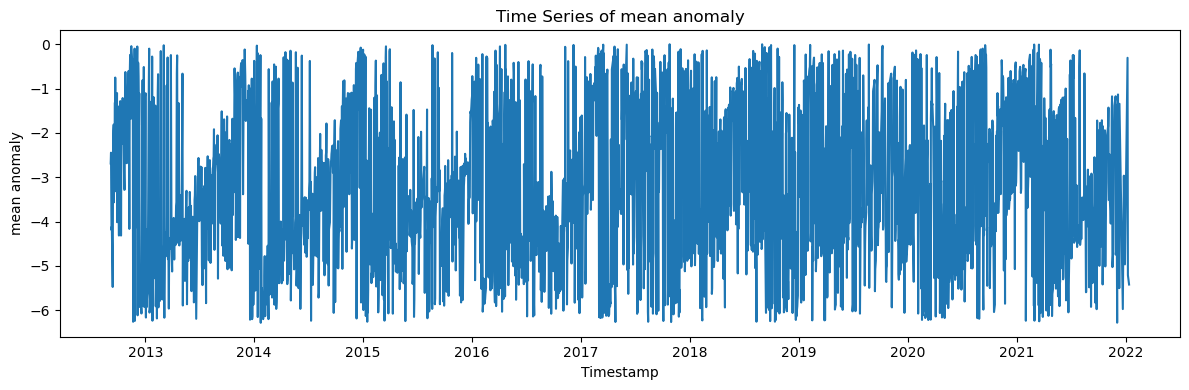

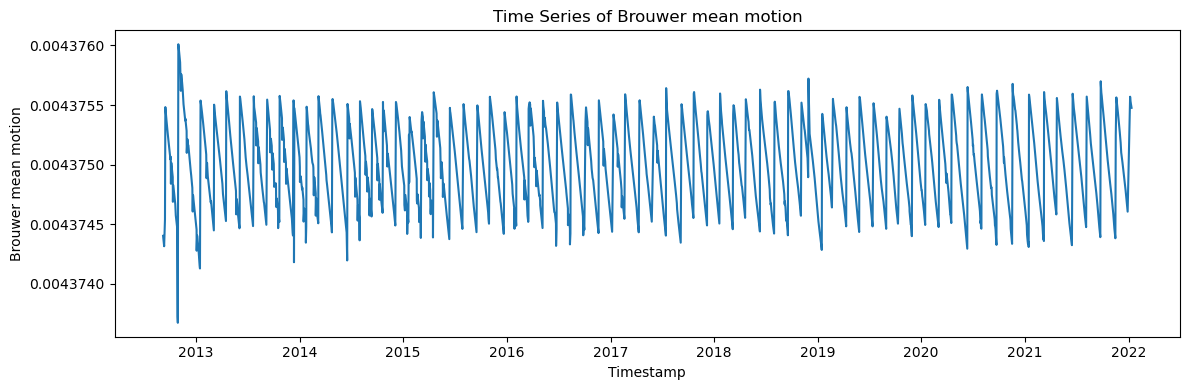

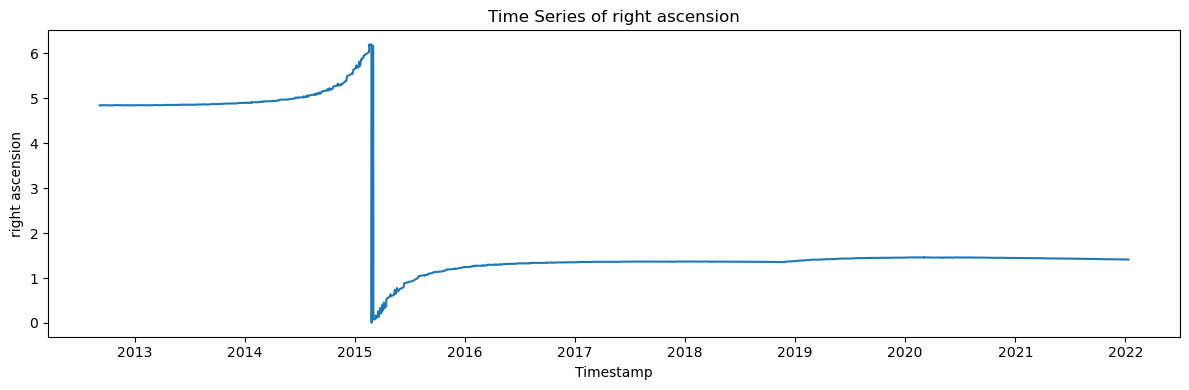

In [4]:
# EDA for orbital elements

def exploratory_analysis(df):
    print("\n--- Descriptive Statistics ---")
    print(df.describe())

    print("\n--- Null Values ---")
    print(df.isnull().sum())

    print("\n--- Correlation Matrix ---")
    corr = df.corr()
    print(corr)

    # Heatmap of correlations
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix of Orbital Elements")
    plt.show()

    # Time-series trend plot
    for col in df.columns:
        plt.figure(figsize=(12, 4))
        sns.lineplot(x=df.index, y=df[col])
        plt.title(f"Time Series of {col}")
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
exploratory_analysis(orb_df)

<Figure size 1000x400 with 0 Axes>

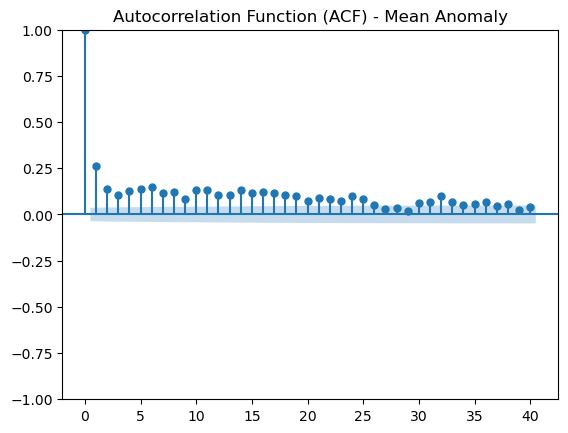

<Figure size 1000x400 with 0 Axes>

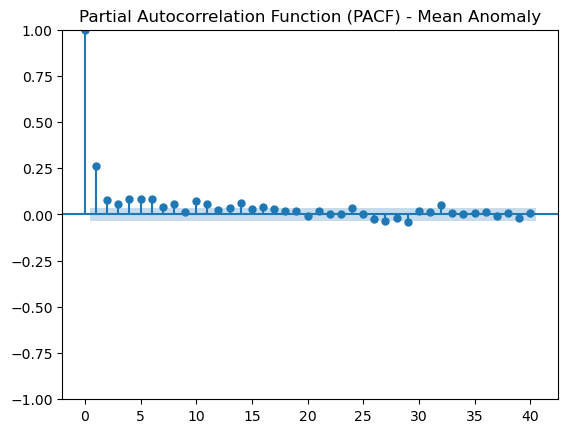


 ADF Test
ADF Statistic     : -7.838658
p-value           : 0.000000
Critical Values   :
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

 The series is stationary.


In [5]:
# EDA for 'mean anomaly'

series = orb_df['mean anomaly'].dropna()

# ACF plot
plt.figure(figsize=(10, 4))
plot_acf(series, lags=40)
plt.title('Autocorrelation Function (ACF) - Mean Anomaly')
plt.show()

# PACF plot
plt.figure(figsize=(10, 4))
plot_pacf(series, lags=40, method='ywm')
plt.title('Partial Autocorrelation Function (PACF) - Mean Anomaly')
plt.show()

# ADF Test
result = adfuller(series)
print('\n ADF Test')
print(f"ADF Statistic     : {result[0]:.6f}")
print(f"p-value           : {result[1]:.6f}")
print(f"Critical Values   :")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")
if result[1] < 0.05:
    print("\n The series is stationary.")
else:
    print("\n The series is NOT stationary.")


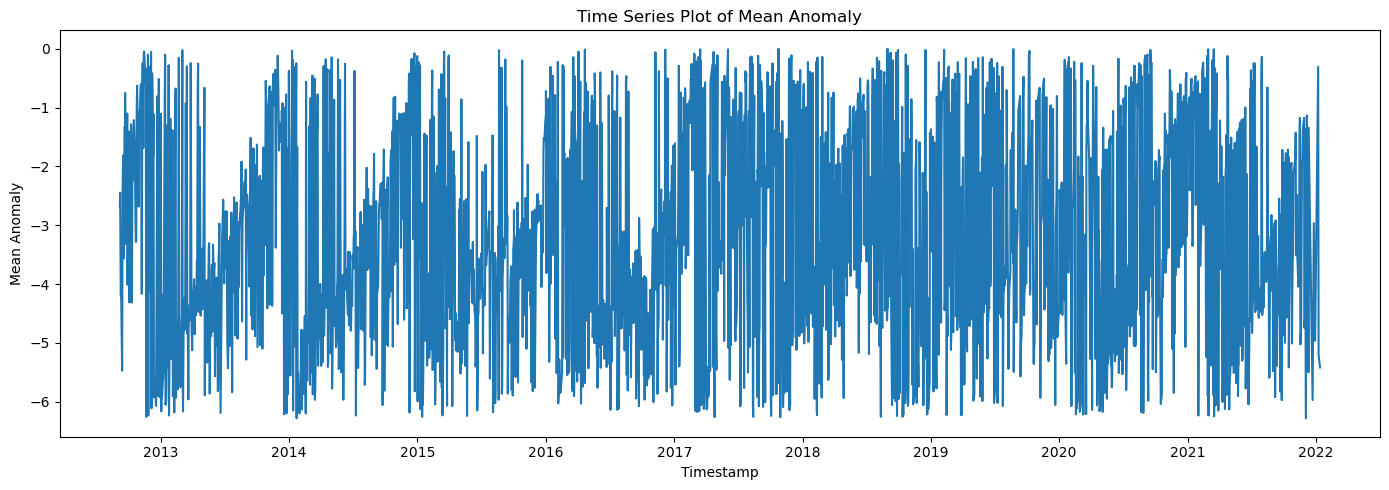

In [6]:
# time series to observe trend


def plot_mean_anomaly_trend(df):
    plt.figure(figsize=(14, 5))
    sns.lineplot(x=df.index, y=df['mean anomaly'])
    plt.title("Time Series Plot of Mean Anomaly")
    plt.xlabel("Timestamp")
    plt.ylabel("Mean Anomaly")
    plt.tight_layout()
    plt.show()

# Call function with your orbital dataframe
plot_mean_anomaly_trend(orb_df)

In [7]:
orb_df = orb_df.sort_index()
orb_df.index = pd.to_datetime(orb_df.index)


# Resample to daily frequency
ra_daily = orb_df['mean anomaly'].resample('D').mean().ffill()

# Use the resampled series
series = ra_daily.dropna()

=== Original Mean Anomaly ===
ADF Statistic: -7.8387
p-value: 0.0000
Result: Stationary




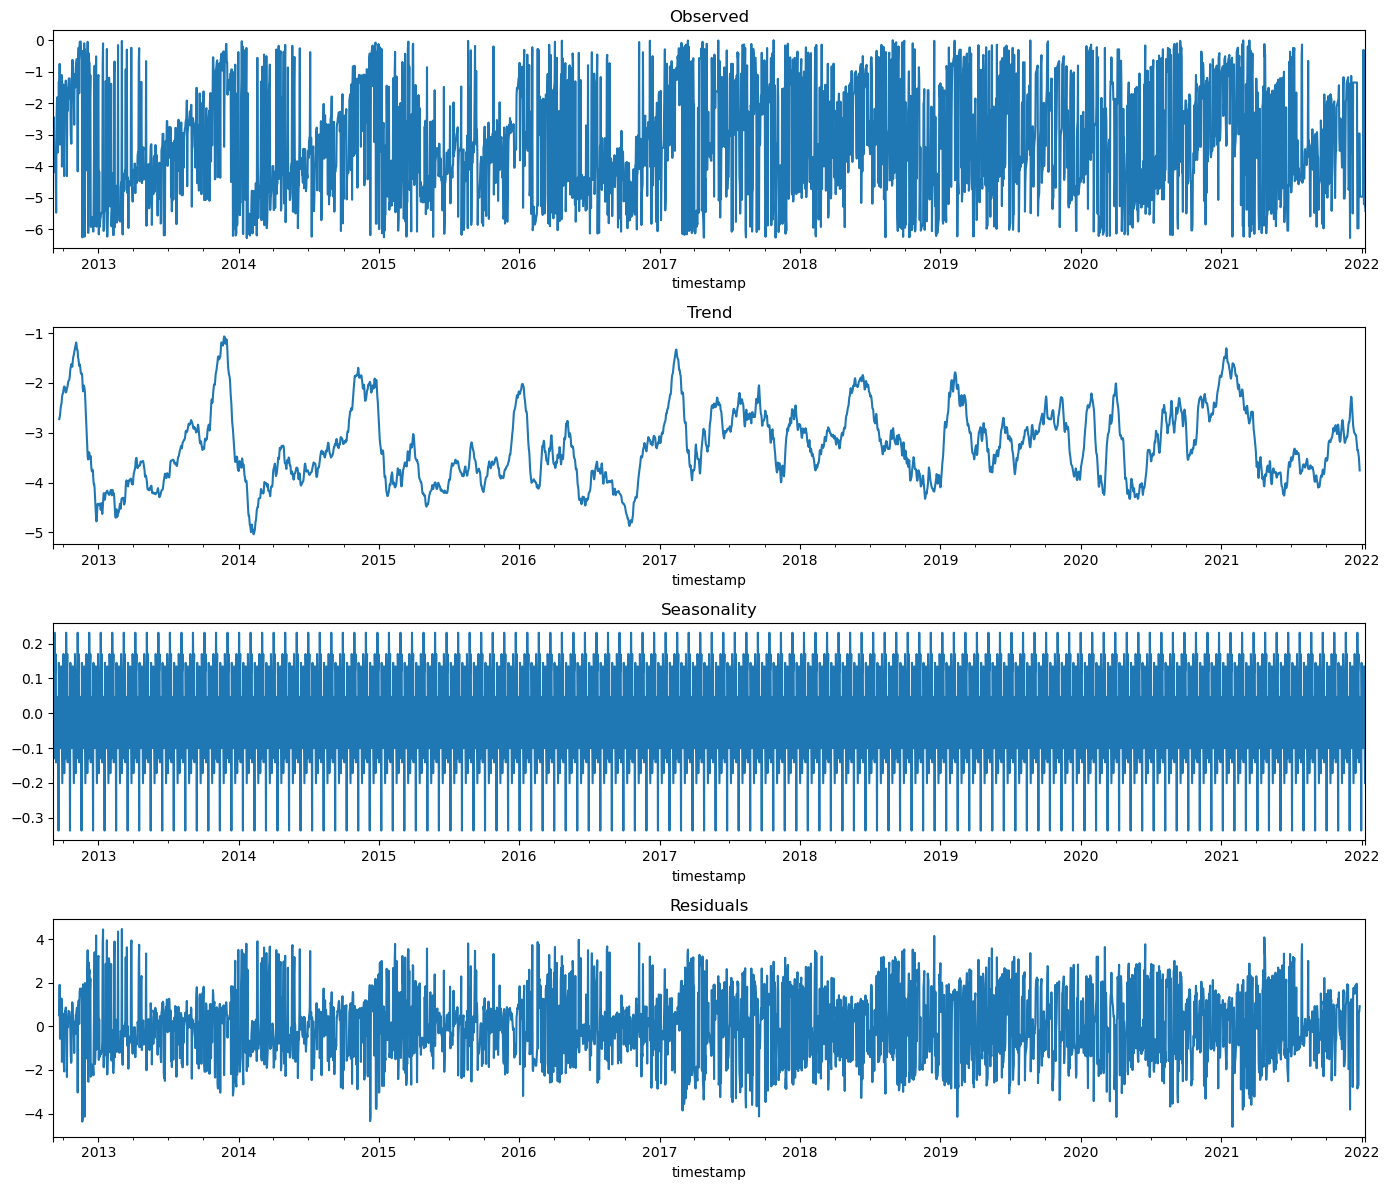

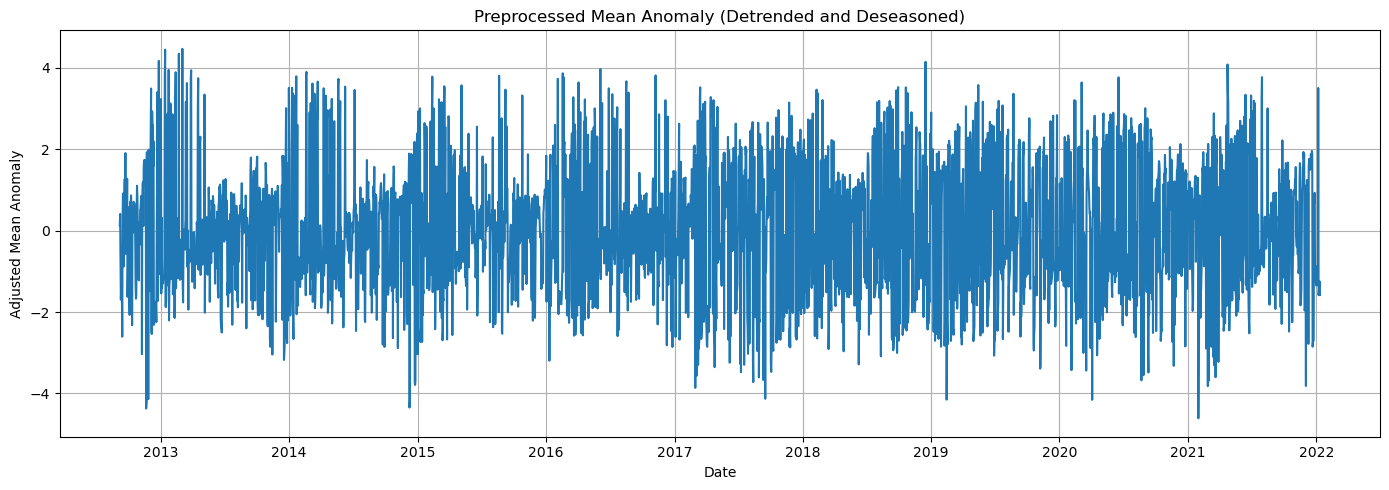

=== Preprocessed Series ===
ADF Statistic: -17.8860
p-value: 0.0000
Result: Stationary




In [8]:
# Checking stationarity and decomposing 

# Fill missing values in mean anomaly 
if orb_df['mean anomaly'].isna().sum() > 0:
    orb_df['mean anomaly'] = orb_df['mean anomaly'].fillna(method='ffill')

# Stationarity check
def test_stationarity(series, title):
    result = adfuller(series.dropna())
    print(f'=== {title} ===')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Result: {"Stationary" if result[1] < 0.05 else "Non-stationary"}')
    print("\n")
    return result[1] < 0.05

is_stationary = test_stationarity(orb_df['mean anomaly'], "Original Mean Anomaly")

ma_daily = orb_df['mean anomaly'].resample('D').mean().ffill()
period = 30  # Adjust as needed
decomposition = seasonal_decompose(ma_daily, model='additive', period=period)

#  decomposition 
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residuals')
plt.tight_layout()
plt.show()

# Preprocessing detrend and deseason ---
trend = decomposition.trend.ffill().bfill()
seasonal = decomposition.seasonal.ffill().bfill()
detrended_deseasoned = ma_daily - trend - seasonal

# preprocessed mean anomaly
plt.figure(figsize=(14, 5))
plt.plot(detrended_deseasoned.index, detrended_deseasoned.values)
plt.title("Preprocessed Mean Anomaly (Detrended and Deseasoned)")
plt.xlabel("Date")
plt.ylabel("Adjusted Mean Anomaly")
plt.grid(True)
plt.tight_layout()
plt.show()

is_preprocessed_stationary = test_stationarity(detrended_deseasoned.dropna(), "Preprocessed Series")
preprocessed_data = detrended_deseasoned.dropna()


Train data shape: (2732,)
Test data shape: (683,)


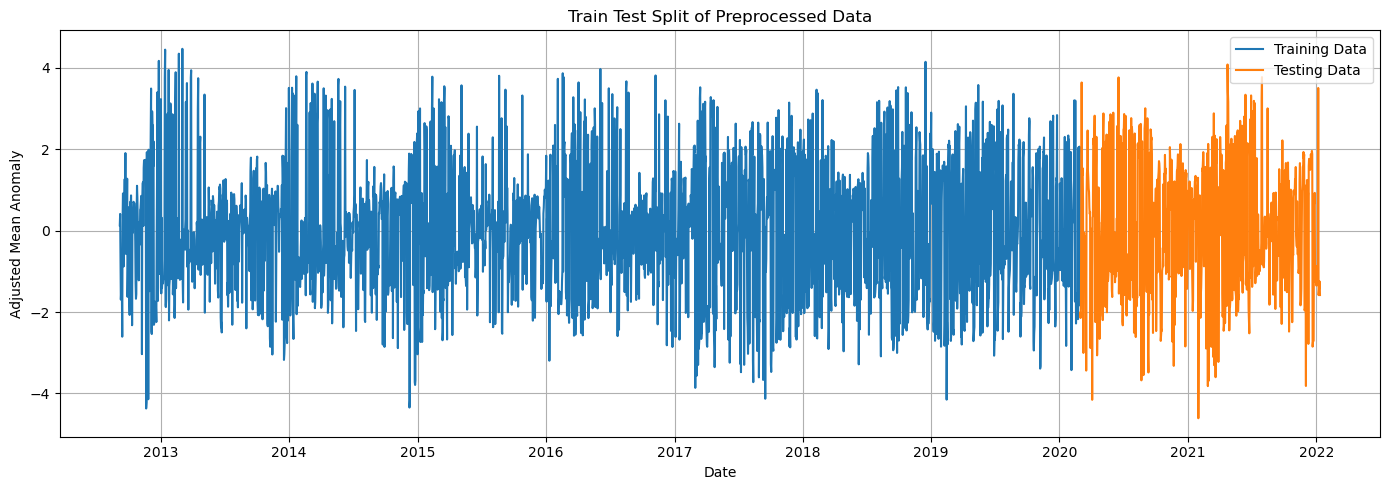

In [9]:
# Train test split

train_size = int(len(preprocessed_data) * 0.8)
train_data = preprocessed_data[:train_size]
test_data = preprocessed_data[train_size:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Visualize the split
plt.figure(figsize=(14, 5))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Testing Data')
plt.title("Train Test Split of Preprocessed Data")
plt.xlabel("Date")
plt.ylabel("Adjusted Mean Anomaly")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
#  Feature engineering 
def create_features(df, target_col='mean anomaly', lags=30):
    if isinstance(df, pd.Series):
        df = df.to_frame(name=target_col)    
    df = df.copy()    
    # Create temporal features
    df['dayofyear'] = df.index.dayofyear
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    
    # lag features
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)  
    # Drop rows with NaN
    df = df.dropna()  
    return df

mean_anomaly_features = create_features(preprocessed_data, target_col='mean anomaly', lags=30)
print(mean_anomaly_features.head())


            mean anomaly  dayofyear  quarter  month  year     lag_1     lag_2  \
timestamp                                                                       
2012-10-06      0.708387        280        4     10  2012 -0.022767 -2.070639   
2012-10-07      0.576338        281        4     10  2012  0.708387 -0.022767   
2012-10-08      0.865950        282        4     10  2012  0.576338  0.708387   
2012-10-09      0.433028        283        4     10  2012  0.865950  0.576338   
2012-10-10      0.277334        284        4     10  2012  0.433028  0.865950   

               lag_3     lag_4     lag_5  ...    lag_21    lag_22    lag_23  \
timestamp                                 ...                                 
2012-10-06 -1.707985  0.575132  0.398303  ...  0.913171  0.252460 -2.605077   
2012-10-07 -2.070639 -1.707985  0.575132  ...  0.867925  0.913171  0.252460   
2012-10-08 -0.022767 -2.070639 -1.707985  ... -0.878816  0.867925  0.913171   
2012-10-09  0.708387 -0.022767 -2.070

In [11]:
target_col = 'mean anomaly'

#Create features for training and test data 
train_features = create_features(preprocessed_data[:train_size], target_col)
test_features = create_features(preprocessed_data[train_size:], target_col)

# Split into training and testing
X_train = train_features.drop(columns=[target_col])
y_train = train_features[target_col]
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

#  Scale features using MinMaxScaler 
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Features Shape: {X_train_scaled.shape}")
print(f"Test Features Shape: {X_test_scaled.shape}")


Training Features Shape: (2702, 34)
Test Features Shape: (653, 34)


In [12]:
#  model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

#  grid 
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Cross Validation
tscv = TimeSeriesSplit(n_splits=3)

In [13]:
# Grid Search
grid_search = GridSearchCV(estimator=xgb_model,
                         param_grid=param_grid,
                         cv=tscv,
                         scoring='neg_mean_squared_error',
                         n_jobs=-1,
                         verbose=1)
grid_search.fit(X_train_scaled, y_train)

# --- Get best model ---
best_xgb = grid_search.best_estimator_
print("\nBest parameters:", grid_search.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}


In [14]:
#  Train final model
best_xgb.fit(X_train_scaled, y_train,
            eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
            verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
test_features = create_features(test_data, target_col)
X_test = test_features.drop(columns=[target_col])
y_test = test_features[target_col]

In [17]:
# Making predictions 
test_predictions = best_xgb.predict(X_test_scaled)

In [18]:
#  RMSE
train_predictions = best_xgb.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"\nTrain RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")


Train RMSE: 1.1713
Test RMSE: 1.5994


In [19]:
print(len(test_data))
print(len(test_predictions))

683
653


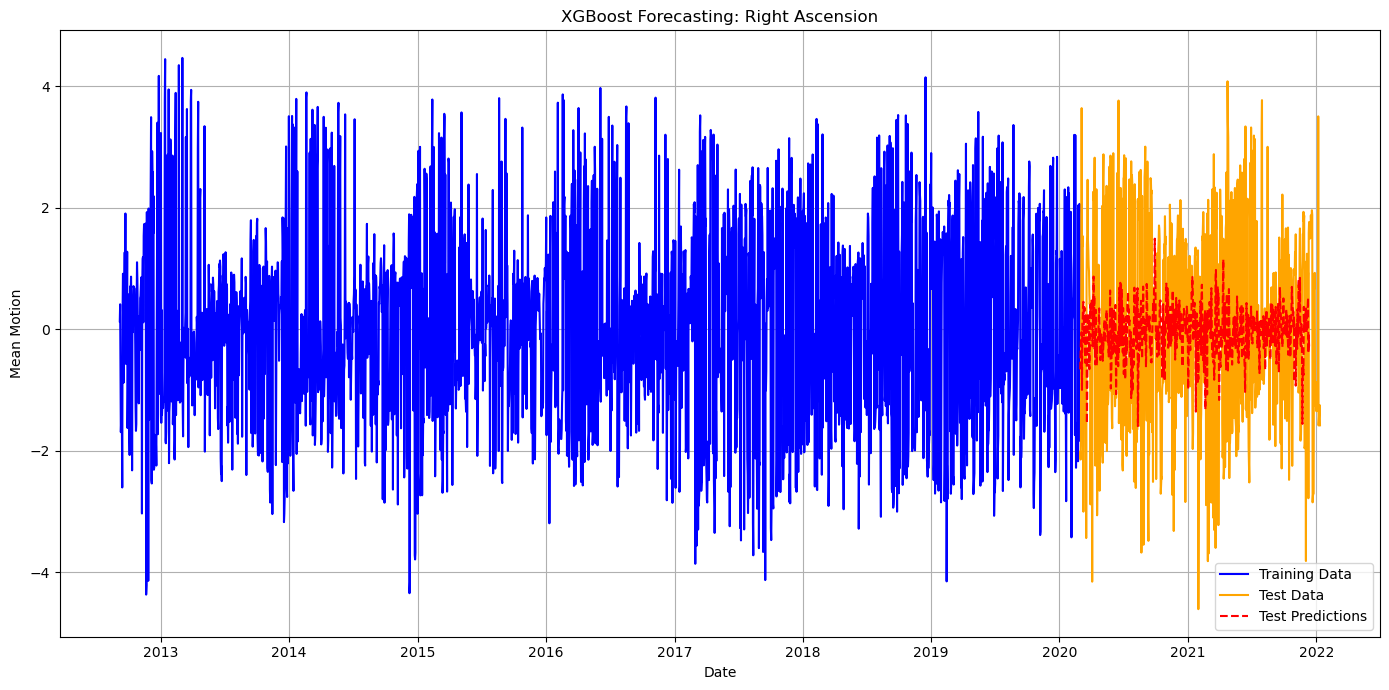

In [20]:
# prediction vs observed
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Test Data', color='orange')
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Test Predictions', color='red', linestyle='--')  
plt.title("XGBoost Forecasting: Right Ascension")
plt.xlabel("Date")
plt.ylabel("Mean Motion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


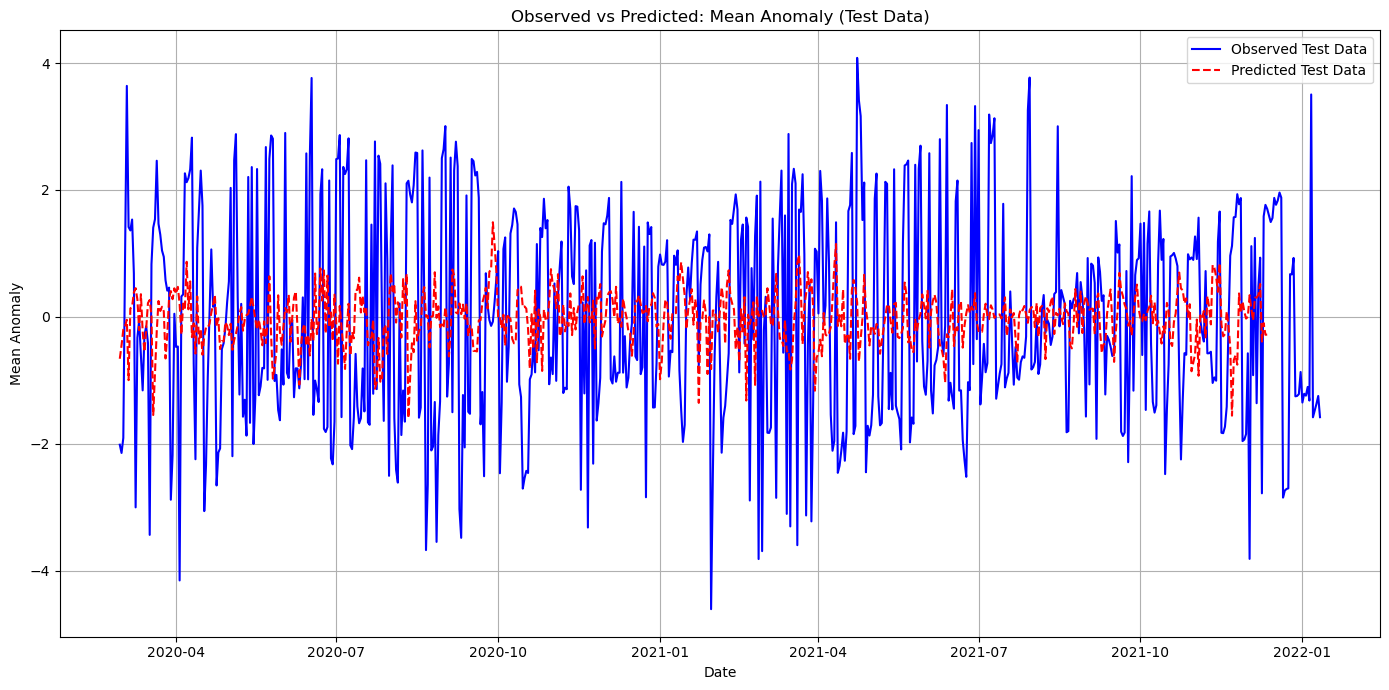

In [21]:
# observed vs predicted for "Mean Motion" test data-
plt.figure(figsize=(14, 7))

# observed values
plt.plot(test_data.index, test_data, label='Observed Test Data', color='blue')

# predicted values
plt.plot(test_data.index[:len(test_predictions)], test_predictions, label='Predicted Test Data', color='red', linestyle='--')

plt.title("Observed vs Predicted: Mean Anomaly (Test Data)")
plt.xlabel("Date")
plt.ylabel("Mean Anomaly")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


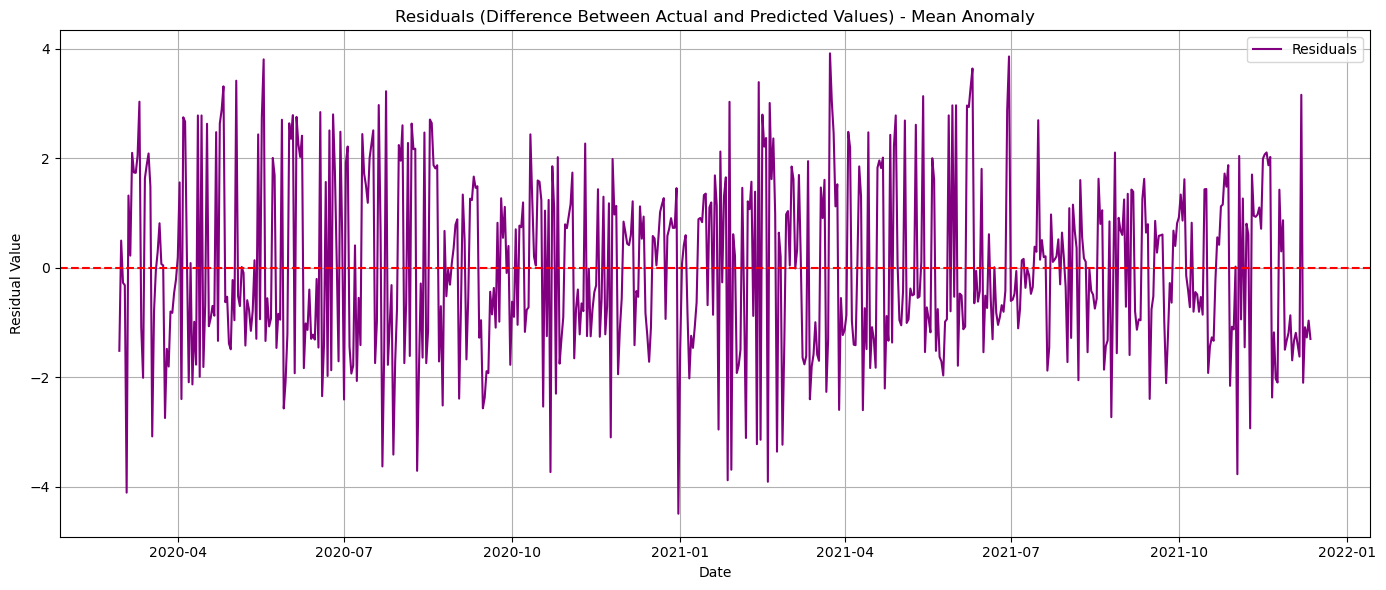

In [22]:
# residuals
residuals = y_test - test_predictions

# plot
plt.figure(figsize=(14, 6))
plt.plot(test_data.index[:len(residuals)], residuals, label='Residuals', color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals (Difference Between Actual and Predicted Values) - Mean Anomaly')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
#  Absolute Residuals 
abs_residuals = np.abs(residuals)

# Threshold for Manoeuvre Detection
threshold_std = abs_residuals.mean() + 2 * abs_residuals.std()
threshold = threshold_std 
print(f"Threshold value used: {threshold:.8f}")

# Detect Manoeuvres 
detected_manoeuvres = residuals[abs_residuals > threshold]
print(f"Number of detected manoeuvre points (Mean Anomaly): {len(detected_manoeuvres)}")

# Group detected points into events (within 1–2 days gap)
detected_dates = detected_manoeuvres.index.tolist()  # Ensure it gets the correct time index
manoeuvre_events = []

if detected_dates:
    current_event = [detected_dates[0]]
    for i in range(1, len(detected_dates)):
        # If the gap between dates is <= 2 days, group them
        if (detected_dates[i] - current_event[-1]).days <= 2:
            current_event.append(detected_dates[i])
        else:
            manoeuvre_events.append({
                'start_time': current_event[0],
                'end_time': current_event[-1],
                'max_residual': abs_residuals[current_event].max()
            })
            current_event = [detected_dates[i]]
    # Add the last event
    manoeuvre_events.append({
        'start_time': current_event[0],
        'end_time': current_event[-1],
        'max_residual': abs_residuals[current_event].max()
    })

# Save Detected Manoeuvre Events to a DataFrame ---
detected_df = pd.DataFrame(manoeuvre_events)
print("\nDetected Manoeuvre Events (Mean Anomaly):")
print(detected_df)


Threshold value used: 3.07631818
Number of detected manoeuvre points (Mean Anomaly): 28

Detected Manoeuvre Events (Mean Anomaly):
   start_time   end_time  max_residual
0  2020-04-03 2020-04-03      4.109524
1  2020-04-17 2020-04-17      3.082032
2  2020-05-26 2020-05-26      3.315800
3  2020-06-02 2020-06-02      3.418398
4  2020-06-17 2020-06-17      3.808545
5  2020-08-21 2020-08-23      3.630651
6  2020-08-27 2020-08-27      3.414556
7  2020-09-09 2020-09-09      3.710869
8  2020-11-21 2020-11-21      3.734245
9  2020-12-24 2020-12-24      3.099697
10 2021-01-30 2021-01-30      4.494733
11 2021-02-26 2021-02-28      3.883321
12 2021-03-08 2021-03-08      3.111048
13 2021-03-14 2021-03-16      3.392178
14 2021-03-20 2021-03-20      3.910806
15 2021-03-25 2021-03-25      3.360550
16 2021-03-28 2021-03-28      3.233949
17 2021-04-23 2021-04-23      3.918525
18 2021-06-13 2021-06-13      3.135788
19 2021-07-09 2021-07-10      3.641838
20 2021-07-30 2021-07-30      3.861477
21 2021-12-

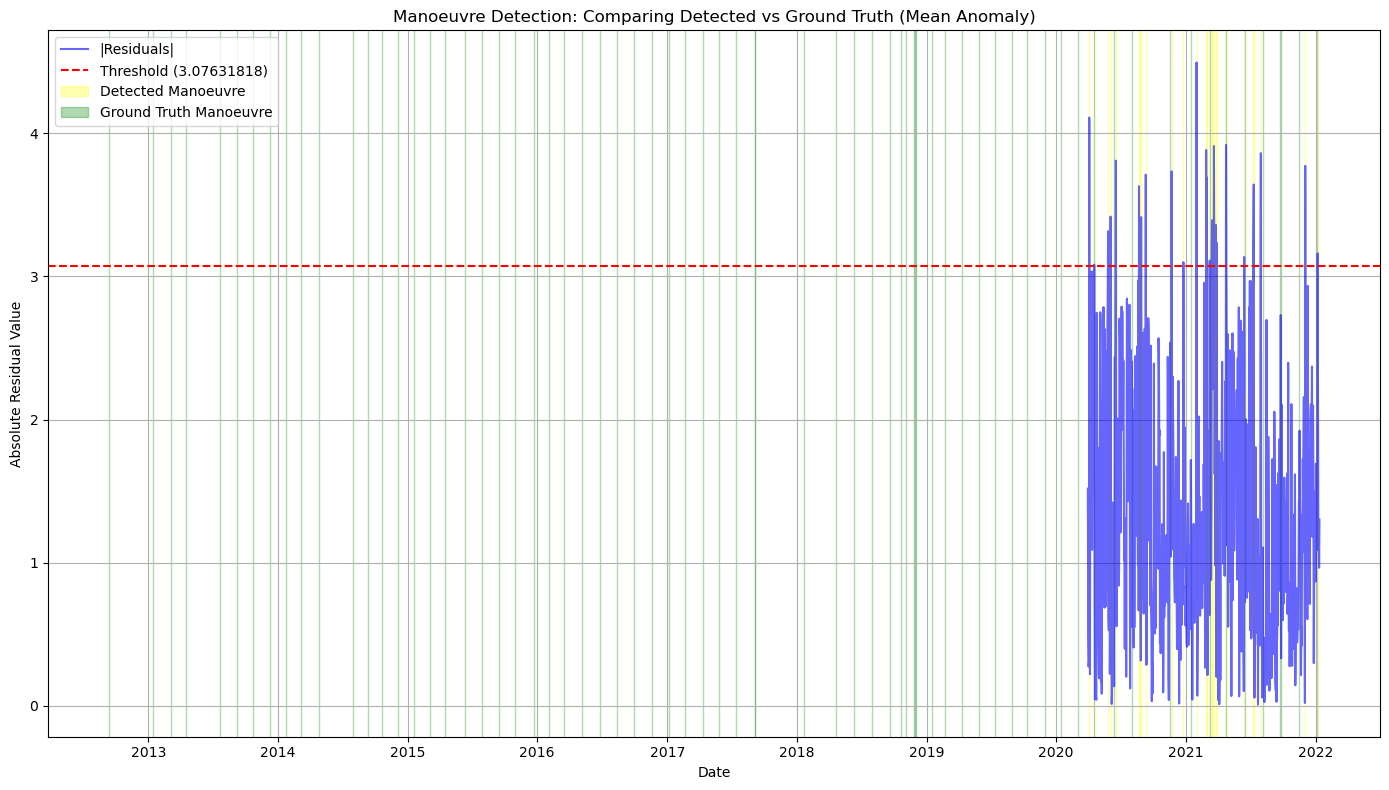

True Positives: 5
False Positives: 18
False Negatives: 63
Precision: 0.2174
Recall: 0.0735
F1 Score: 0.1099


In [24]:
#  Detected Manoeuvres vs Ground Truth 
plt.figure(figsize=(14, 8))

# absolute residuals
plt.plot(abs_residuals.index, abs_residuals, label='|Residuals|', color='blue', alpha=0.6)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')

# detected manoeuvre 
for idx, event in enumerate(manoeuvre_events):
    plt.axvspan(event['start_time'], event['end_time'], 
                alpha=0.3, color='yellow', label='Detected Manoeuvre' if idx == 0 else '')

# ground truth manoeuvres
for idx, row in man_df.iterrows():
    plt.axvspan(row['start_time'], row['end_time'], 
                alpha=0.3, color='green', label='Ground Truth Manoeuvre' if idx == 0 else '')

plt.title('Manoeuvre Detection: Comparing Detected vs Ground Truth (Mean Anomaly)')
plt.xlabel('Date')
plt.ylabel('Absolute Residual Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#  Accuracy Metrics ---
def calculate_detection_accuracy(detected_df, ground_truth_df, tolerance_days=3):
    true_positives = 0
    false_positives = 0
    for _, det_event in detected_df.iterrows():
        matched = False
        for _, gt_event in ground_truth_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break

        if matched:
            true_positives += 1
        else:
            false_positives += 1

    # False negatives
    false_negatives = 0
    for _, gt_event in ground_truth_df.iterrows():
        matched = False
        for _, det_event in detected_df.iterrows():
            if (
                (det_event['start_time'] <= gt_event['end_time'] and 
                 det_event['end_time'] >= gt_event['start_time']) or
                (abs((det_event['start_time'] - gt_event['start_time']).days) <= tolerance_days or
                 abs((det_event['end_time'] - gt_event['end_time']).days) <= tolerance_days)
            ):
                matched = True
                break
        if not matched:
            false_negatives += 1

    # Metrics
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score
    }

metrics = calculate_detection_accuracy(detected_df, man_df)
print(f"True Positives: {metrics['true_positives']}")
print(f"False Positives: {metrics['false_positives']}")
print(f"False Negatives: {metrics['false_negatives']}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")


In [25]:
#  summary tables

# Detected Manoeuvres (based on XGBoost prediction)
print("\n[ XGBoost ] Detected Manoeuvres (Mean Anomaly):")
print(detected_df[['start_time', 'end_time', 'max_residual']])

# Ground Truth Manoeuvres (for Mean Anomaly, assuming man_df contains the ground truth for Mean Anomaly)
print("\nGround Truth Manoeuvres (Mean Anomaly):")
print(man_df[['start_time', 'end_time']])



[ XGBoost ] Detected Manoeuvres (Mean Anomaly):
   start_time   end_time  max_residual
0  2020-04-03 2020-04-03      4.109524
1  2020-04-17 2020-04-17      3.082032
2  2020-05-26 2020-05-26      3.315800
3  2020-06-02 2020-06-02      3.418398
4  2020-06-17 2020-06-17      3.808545
5  2020-08-21 2020-08-23      3.630651
6  2020-08-27 2020-08-27      3.414556
7  2020-09-09 2020-09-09      3.710869
8  2020-11-21 2020-11-21      3.734245
9  2020-12-24 2020-12-24      3.099697
10 2021-01-30 2021-01-30      4.494733
11 2021-02-26 2021-02-28      3.883321
12 2021-03-08 2021-03-08      3.111048
13 2021-03-14 2021-03-16      3.392178
14 2021-03-20 2021-03-20      3.910806
15 2021-03-25 2021-03-25      3.360550
16 2021-03-28 2021-03-28      3.233949
17 2021-04-23 2021-04-23      3.918525
18 2021-06-13 2021-06-13      3.135788
19 2021-07-09 2021-07-10      3.641838
20 2021-07-30 2021-07-30      3.861477
21 2021-12-02 2021-12-02      3.772519
22 2022-01-06 2022-01-06      3.160858

Ground Truth M

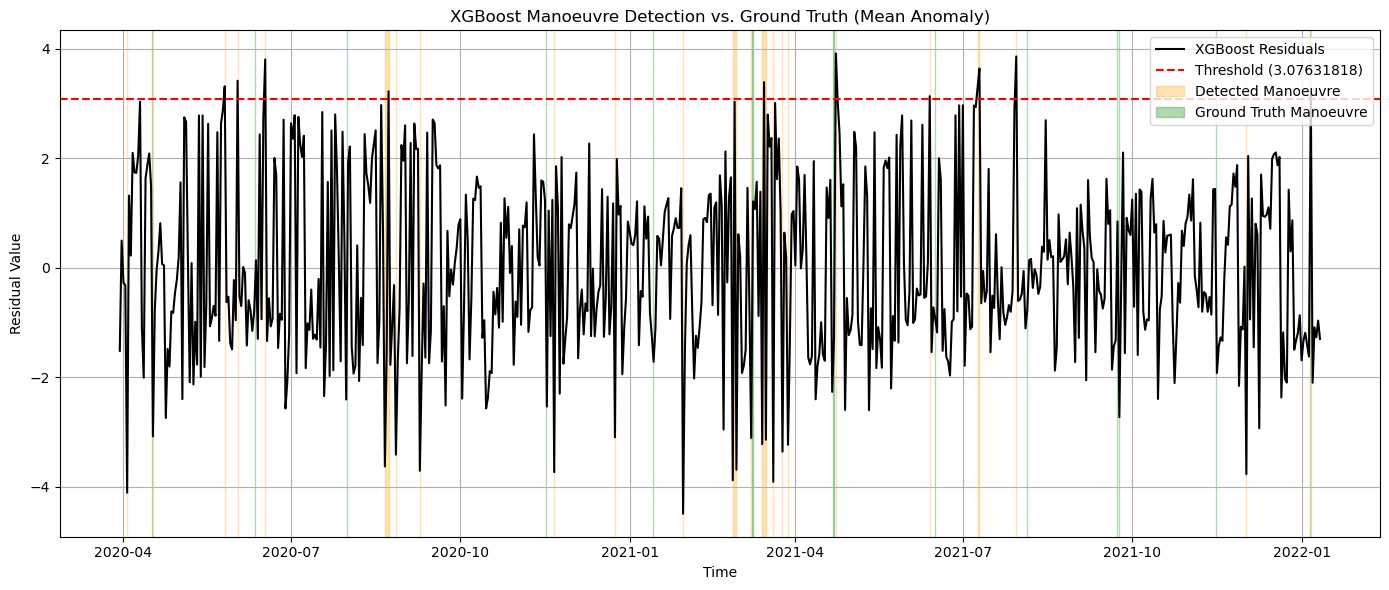

In [26]:
# Filter ground truth manoeuvres
man_df_filtered = man_df[
    (man_df['start_time'] >= residuals.index.min()) &
    (man_df['end_time'] <= residuals.index.max())
]

plt.figure(figsize=(14, 6))

#  residuals for Mean Anomaly
plt.plot(residuals.index, residuals.values, label='XGBoost Residuals', color='black')

# threshold line 
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.8f})')

#  detected manoeuvres
if not detected_df.empty:
    for idx, row in detected_df.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='orange', alpha=0.3,
                    label='Detected Manoeuvre' if idx == 0 else "")

# ground truth manoeuvres 
if not man_df_filtered.empty:
    for idx, row in man_df_filtered.iterrows():
        plt.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.3,
                    label='Ground Truth Manoeuvre' if idx == 0 else "")

plt.xlabel('Time')
plt.ylabel('Residual Value')
plt.title('XGBoost Manoeuvre Detection vs. Ground Truth (Mean Anomaly)')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


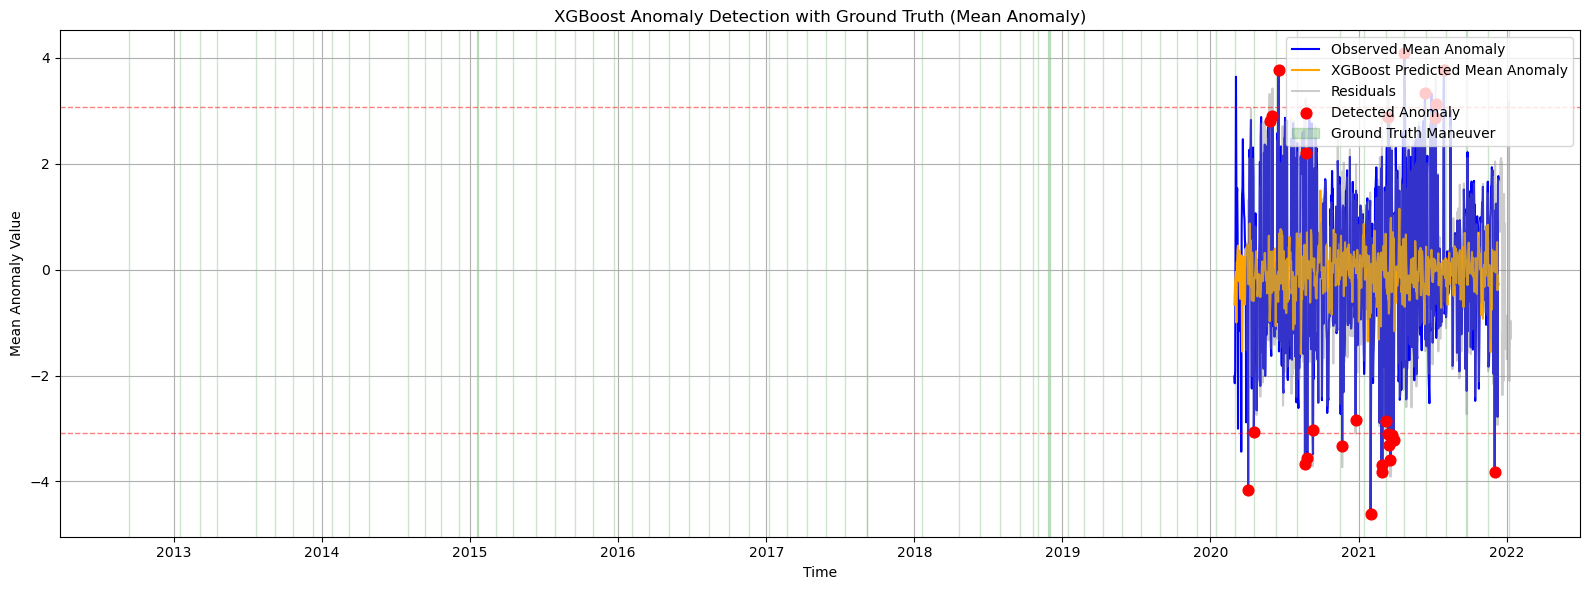

In [27]:

def detect_anomalies(residuals, threshold):
    anomaly_mask = residuals.abs() > threshold
    return residuals[anomaly_mask]

def plot_all_in_one_xgboost(observed, predicted, residuals, threshold, man_df):
    if len(predicted) != len(observed):
        print(f"Warning: Length mismatch. Observed: {len(observed)}, Predicted: {len(predicted)}")
        min_len = min(len(observed), len(predicted))
        observed = observed[:min_len]
        predicted = predicted[:min_len]
        residuals = residuals[:min_len]

    predicted = pd.Series(predicted, index=observed.index)
    anomalies = detect_anomalies(residuals, threshold)
    anomalies = anomalies[anomalies.index.isin(observed.index)]

    fig, ax = plt.subplots(figsize=(16, 6))

    #  Observed and Predicted
    ax.plot(observed.index, observed.values, label='Observed Mean Anomaly', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted Mean Anomaly', color='orange', linewidth=1.5)

    #  residuals
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.4, label='Residuals')

    # anomalies 
    ax.scatter(anomalies.index, observed.loc[anomalies.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    # threshold
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(y=-threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)

    #  Ground Truth Maneuvers 
    for idx, row in man_df.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == 0 else "")

    ax.set_title("XGBoost Anomaly Detection with Ground Truth (Mean Anomaly)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Mean Anomaly Value")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_all_in_one_xgboost(test_data, test_predictions, residuals, threshold, man_df)


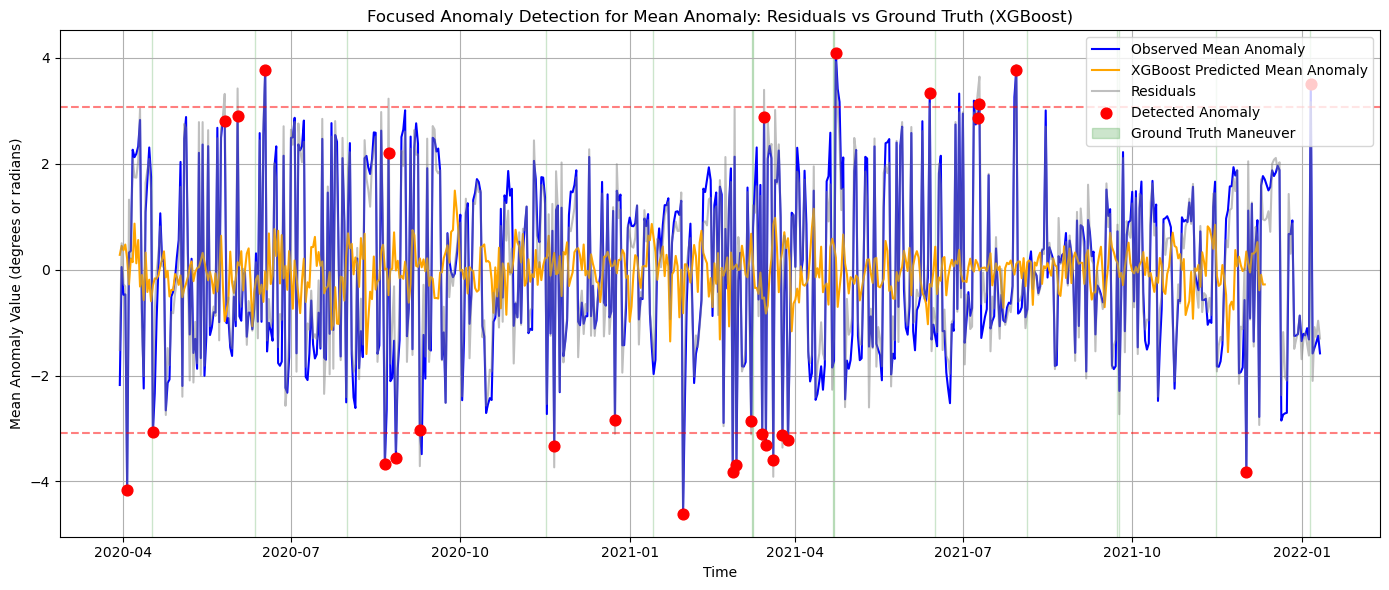

In [28]:
def plot_focused_anomalies_xgboost(observed, predicted, residuals, threshold, man_df):

    if len(predicted) != len(observed):
        predicted = pd.Series(predicted, index=observed.index[:len(predicted)])
    valid_times = residuals.dropna().index
    valid_man = man_df[
        (man_df['end_time'] >= valid_times.min()) &
        (man_df['start_time'] <= valid_times.max())
    ]
    # start and end time 
    plot_start = max(valid_times.min(), predicted.dropna().index.min())
    plot_end = max(valid_times.max(), predicted.dropna().index.max())
    # filter data
    observed = observed[(observed.index >= plot_start) & (observed.index <= plot_end)]
    predicted = predicted[(predicted.index >= plot_start) & (predicted.index <= plot_end)]
    residuals = residuals[(residuals.index >= plot_start) & (residuals.index <= plot_end)]
    anomalies = detect_anomalies(residuals, threshold)
    anomalies = anomalies[(anomalies.index >= plot_start) & (anomalies.index <= plot_end)]
    valid_man = valid_man[
        (valid_man['start_time'] <= plot_end) &
        (valid_man['end_time'] >= plot_start)
    ]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))

    # Observed and Predicted
    ax.plot(observed.index, observed.values, label='Observed Mean Anomaly', color='blue', linewidth=1.5)
    ax.plot(predicted.index, predicted.values, label='XGBoost Predicted Mean Anomaly', color='orange', linewidth=1.5)
    ax.plot(residuals.index, residuals.values, color='grey', alpha=0.5, label='Residuals')

    # Detected anomalies
    ax.scatter(anomalies.index, observed.loc[anomalies.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    # Residual threshold 
    ax.axhline(threshold, linestyle='--', color='red', alpha=0.5)
    ax.axhline(-threshold, linestyle='--', color='red', alpha=0.5)

    # Ground truth 
    for idx, row in valid_man.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == valid_man.index[0] else "")
    ax.set_title("Focused Anomaly Detection for Mean Anomaly: Residuals vs Ground Truth (XGBoost)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Mean Anomaly Value (degrees or radians)")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_focused_anomalies_xgboost(test_data, test_predictions, residuals, threshold, man_df)


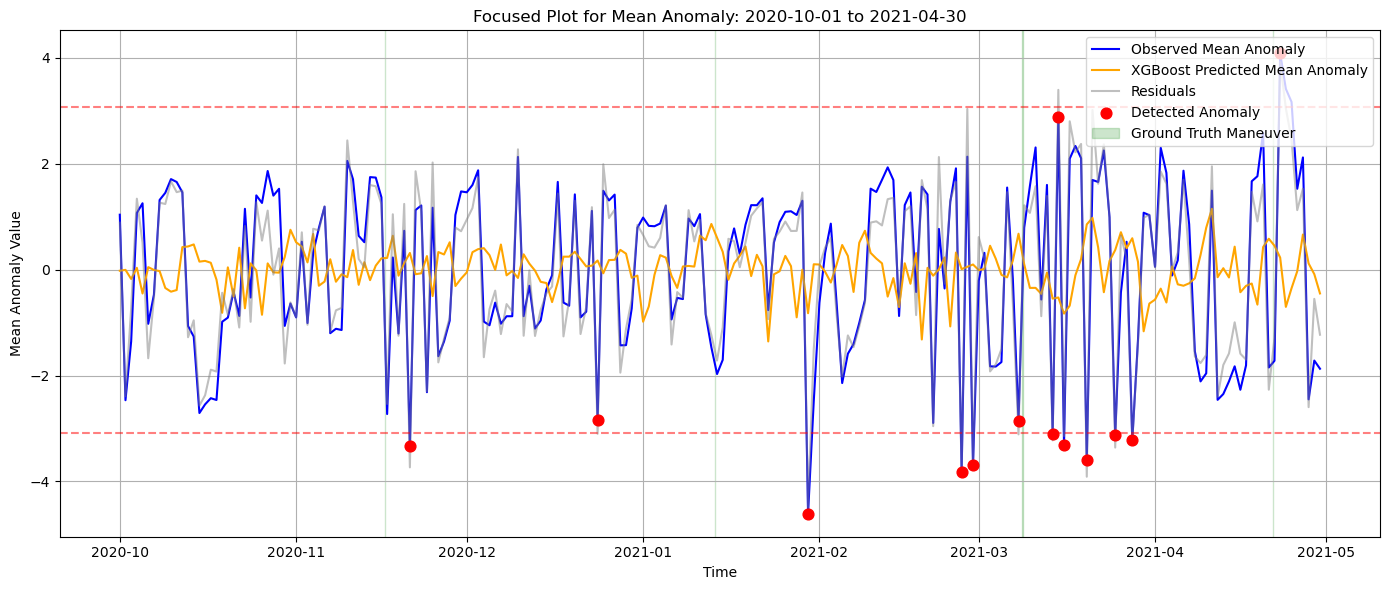

In [29]:

def plot_focused_window(observed, predicted, residuals, threshold, man_df, start_time, end_time):
    if isinstance(predicted, (list, np.ndarray)):
        predicted = pd.Series(predicted, index=observed.index[:len(predicted)])

    start_time = pd.to_datetime(start_time)
    end_time = pd.to_datetime(end_time)

    # Filter data
    observed_focus = observed[(observed.index >= start_time) & (observed.index <= end_time)]
    predicted_focus = predicted[(predicted.index >= start_time) & (predicted.index <= end_time)]
    residuals_focus = residuals[(residuals.index >= start_time) & (residuals.index <= end_time)]

    # Detect anomalies
    anomalies_focus = detect_anomalies(residuals_focus, threshold)
    man_df_focus = man_df[
        (man_df['start_time'] <= end_time) &
        (man_df['end_time'] >= start_time)
    ]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(observed_focus.index, observed_focus.values, label='Observed Mean Anomaly', color='blue', linewidth=1.5)
    ax.plot(predicted_focus.index, predicted_focus.values, label='XGBoost Predicted Mean Anomaly', color='orange', linewidth=1.5)
    ax.plot(residuals_focus.index, residuals_focus.values, color='grey', alpha=0.5, label='Residuals')

    # anomalies
    ax.scatter(anomalies_focus.index, observed_focus.loc[anomalies_focus.index], color='red', s=60, label='Detected Anomaly', zorder=5)

    # Threshold 
    ax.axhline(threshold, linestyle='--', color='red', alpha=0.5)
    ax.axhline(-threshold, linestyle='--', color='red', alpha=0.5)

    # Ground truth
    for idx, row in man_df_focus.iterrows():
        ax.axvspan(row['start_time'], row['end_time'], color='green', alpha=0.2,
                   label='Ground Truth Maneuver' if idx == man_df_focus.index[0] else "")
    ax.set_title(f"Focused Plot for Mean Anomaly: {start_time.date()} to {end_time.date()}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Mean Anomaly Value")
    ax.legend(loc='upper right')
    ax.grid(True)
    plt.tight_layout()
    plt.show()


plot_focused_window(test_data,test_predictions, residuals,threshold,man_df,start_time='2020-10-01',end_time='2021-04-30'
)
